# Backprop and Gradient Descent Test
MLPs, SGD, MSE, all of the 3 letter acronyms

## Section 1 (15 min)

In this section you will derivive the gradient of an MLP with Sigmoid nonlinearities for use in gradient descent

1. For the following nonlinearity, calculate the derivative of it w.r.t (with respect to) its input -- this was on the previous test, but now you must simplify (hint: $\sigma(X)$ will appear in your solution):

\begin{align*}
    σ(X) = \frac{1}{1+e^{-X}}
\end{align*}

\begin{align*}
    \frac{∂σ}{∂X}= \sigma(X)*(1-\sigma(X))
\end{align*}

2. Imagining that we’re using this nonlinearity after a single layer of neural network – calculate the derivative of the output w.r.t the weights.

\begin{align*}
    A = X \cdot W + b \quad \text{  and  } \quad \hat{y} = σ(A) = \frac{1}{1+e^{-A}}
\end{align*}

\begin{align*}
    \frac{∂\hat{y}}{∂W}= X^T (\sigma(WX+B)*(1-\sigma(WX+B)))
\end{align*}

3. Now consider finding the derivative of a model with an additional layer like so:

\begin{align*}
    \hat{y} = (σ(X\cdot W_{0}+b_{0})) \cdot W_{1} + b_{1}
\end{align*}

\begin{align*}
    \frac{∂\hat{y}}{∂W_0}= X^T(\sigma(xw_0+b_0)(1-\sigma(xw_0+b_0))W_1^T)
\end{align*}

4. Describe and implement a modification that can be made to X and W, to X' and W',such that:

\begin{align*}
    X \cdot W + b = X' \cdot W'
\end{align*}

In [78]:
'add a row of ones to the matrix and an extra weight equal to the bias when multiplyin'

'add a row of ones to the matrix and an extra weight equal to the bias when multiplyin'

Describe here:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def modify_x_w(x, w, b):
    '''
    You may assume that x,w, and b are all given as np arrays
    '''
    if (x.ndim == 1):
        x = x.reshape(1,-1)
    

    newcol = (np.array(b))
    newcol = newcol.reshape(1,-1)
    newrow = ((np.ones((x.shape[0],1))))
    X_new = np.hstack((x,newrow))
    W_new = np.vstack((w,newcol))

    

    return X_new, W_new

In [4]:
# Test for your implementation
import numpy as np

# test vectors:
X = np.array([1,2,3,4])
W = np.ones((4,2))
b = np.ones(2)

X_new, W_new = modify_x_w(X,W,b)

print("original (vector): " + str((X @ W) + b))
print("modified (vector): " + str((X_new @ W_new)))

# test matrices:
X = np.array(([1,2,3], [4,5,6]))
W = np.array(([1,2,3,10], [4,5,6,10], [7,8,9,10]))
b = np.array([[5,4,6,9]])

X_new, W_new = modify_x_w(X,W,b)

print("original (matrix): " + str((X @ W) + b))
print("modified (matrix): " + str((X_new @ W_new)))

original (vector): [11. 11.]
modified (vector): [[11. 11.]]
original (matrix): [[ 35  40  48  69]
 [ 71  85 102 159]]
modified (matrix): [[ 35.  40.  48.  69.]
 [ 71.  85. 102. 159.]]


## Section 2 (15 min)
In this section you will create a dataset and plot it

1. Create a function to sample n points from the following distribution:

\begin{align*}
X \sim U[-1, 1], \quad \quad
Y \sim U[-1, 1], \quad \quad          
Err \sim N(0, 0.5) \\ \\
Z = X^2 - Y^2 + 1.2 + Err
\end{align*}

The function should return an n x 3 matrix

In [5]:
np.random.seed(42)
def sample_points(n):
    '''
    Sample from the above function n times and return the resultant n x 3 matrix as an np array
    Ensure that the order of the colomns are X, Y, Z (i.e. points[:][2] should be an nx1 col of just the Z values)
    '''
    
    points = np.ones((n, 3))
    xpoints = np.random.uniform(-1, 1, n)
    ypoints = np.random.uniform(-1, 1, n)
    errors = np.random.normal(0, 0.5, n)
    zpoints = xpoints**2 - ypoints**2 + 1.2 + errors
    points[:, 0] = xpoints
    points[:, 1] = ypoints
    points[:, 2] = zpoints
    return points
print(sample_points(5))

[[-0.25091976 -0.68801096  0.55486445]
 [ 0.90142861 -0.88383278  1.50269319]
 [ 0.46398788  0.73235229  0.64723603]
 [ 0.19731697  0.20223002  0.96517213]
 [-0.68796272  0.41614516  1.62109705]]


2. Now plot these points as a 3d scatter plot using matplotlib, x, y, and z should correspond to their respective axes. The points should be colored (*) according to their z value (blue is low, red is high) and should have opacity 0.5.

In [6]:
import matplotlib.pyplot as plt

def plot_3d_scatter(points):
    fig = plt.figure()

    ax = fig.add_subplot(projection = '3d')
    x = points[:,0]
    y = points[:,1]
    z = points[:,2]
    ax.scatter(x,y,z,c =z,cmap ='coolwarm',alpha = 0.5)
    
    plt.show()
    return None

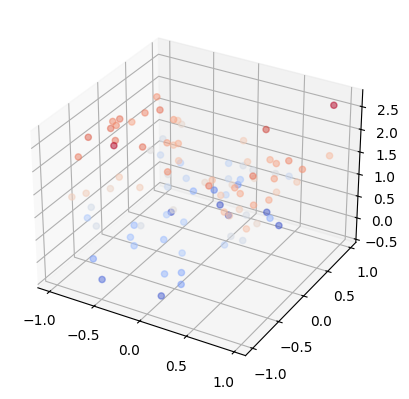

In [7]:
# Test for sampling and plotting:

points = sample_points(100)
plot_3d_scatter(points)

3. Next create a function that will create a train and test dataset of size 100 and 20 respectively. Then plot both on the same 3d scatter in different shapes.

In [8]:
def create_train_and_test(train_size=100, test_size=20):
    training = sample_points(100)
    testing = sample_points(20)
    return training, testing
print(create_train_and_test())

(array([[-0.65359626, -0.25145841,  1.05176292],
       [-0.1322967 , -0.25871571,  1.50637604],
       [-0.20299053,  0.62559913,  0.28750983],
       [ 0.2317002 ,  0.89449715, -0.31349726],
       [ 0.2701873 ,  0.97200213,  0.96705145],
       [-0.90939198,  0.50675637,  1.93634876],
       [-0.25077477, -0.24748083,  0.82739796],
       [ 0.25171983, -0.83299857,  1.34505225],
       [ 0.00627252,  0.55429383,  0.95063501],
       [ 0.71297968,  0.1168085 ,  2.28434439],
       [ 0.31738726, -0.15155598,  1.3115247 ],
       [-0.67413115,  0.81270877,  2.02433122],
       [-0.85886251, -0.77760504,  2.21064563],
       [ 0.28483856, -0.01474979,  1.15643337],
       [-0.94697738, -0.97729271,  1.62745059],
       [ 0.17155116, -0.06267872,  1.54818915],
       [ 0.88046048, -0.88739345,  1.87205931],
       [ 0.15094836, -0.76236417,  0.15912455],
       [-0.22366015, -0.76494751,  1.0079049 ],
       [ 0.28657644,  0.2984206 ,  1.72228344],
       [-0.08349422,  0.49208976,  0.08

In [9]:
def plot_train_and_test(train_data, test_data):
    plot_3d_scatter(train_data)
    plot_3d_scatter(test_data)
    
    

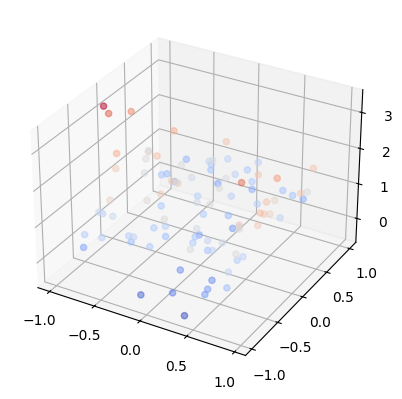

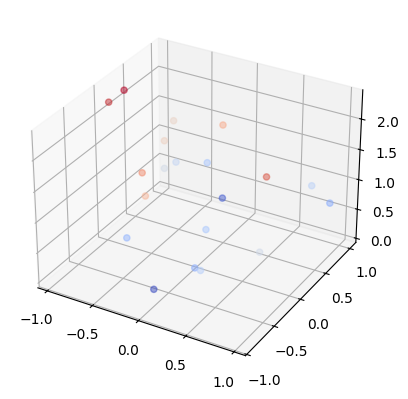

In [10]:
# Test your code
train_data, test_data = create_train_and_test()
plot_train_and_test(train_data, test_data)

# Section 3 (10 min)
Now we will initilize a model to train on this data

1. First we intialize weights, create a function that will initialize an IN x OUT size weight matrix with each value sampled from a normal distribution with mean 1 and std 0.25

In [11]:
import numpy as np

def init_weight_matrix(In=2, Out=1):
    weight_matrix = np.random.normal(1,0.25,(In,Out))
    return weight_matrix

In [12]:
# test this

test_mat = init_weight_matrix(5, 10)
print(test_mat)
print(test_mat.shape)
print(np.mean(test_mat))

[[1.44863947 0.87059718 1.05594699 0.99589428 1.29709832 1.63173311
  0.86728281 0.87764014 1.26104022 1.17047287]
 [1.46167683 1.14598205 0.91017698 1.14766371 1.2771759  1.20512055
  1.12681851 1.26666867 1.2923239  1.34553975]
 [1.16217747 0.95822048 1.03667842 1.30162724 0.79576608 1.09216833
  0.9016653  1.00718621 1.31961297 1.04777477]
 [1.01160914 0.66003596 1.18656339 1.16137105 1.54081368 0.92305544
  1.05478758 1.06234592 1.39436332 0.97617612]
 [1.06975538 1.15197413 1.04665228 0.8883916  1.0485225  1.26840794
  0.74337118 1.03324242 0.8249698  1.29876166]]
(5, 10)
1.112470798509544


2. Now we want to be able to initialize an MLP. We will be given a list of output sizes for our matrices. Since the data we are using as input is 2d the first matrix will always have an input size of the first element of the list but subsequent layers will have input size equal to the previous layers output size. e.g. a size list [2,5,10,1] should produce a 2x5, 5x10, and 10x1 sized matrices.

The model should be given as a dictionary with the key 'W+str(n)' corresponding to the n-th weight matrix of the MLP.

In [13]:
def init_mlp(output_sizes=[5,1]):
    model = {}
    for i in range(len(output_sizes)-1):
        model["W"+str(i)] = init_weight_matrix(output_sizes[i], output_sizes[i+1])
    return model

In [14]:
# test

test_mlp = init_mlp([10,5,2,1])

for layer in test_mlp:
    print('layer : ' + layer)
    print(test_mlp[layer].shape)

layer : W0
(10, 5)
layer : W1
(5, 2)
layer : W2
(2, 1)


# Section 4 (10 min)
Now we will complete the forward pass and loss calculation of our model

1. First let's complete the forward pass of the sigmoid function (we will use this as our nonlinearity).

In [15]:
def sigmoid_forward(x):
    '''
    returns the output of the sigmoid non-linearity performed on input X (elementwise)
    '''
    return 1/(1+np.exp(-x))

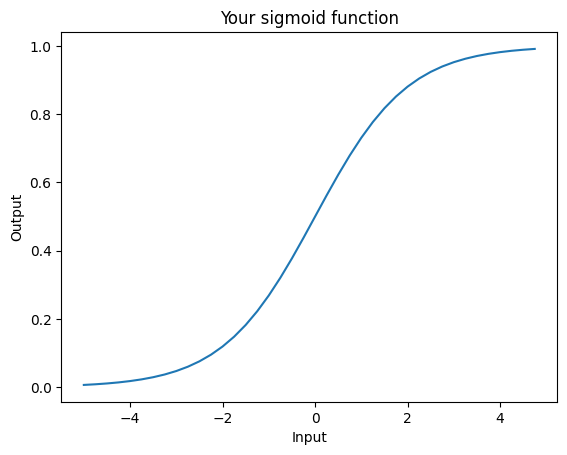

In [16]:
import matplotlib.pyplot as plt
import numpy as np

example_inputs = np.arange(-5,5,0.25)
your_output = sigmoid_forward(example_inputs)

plt.plot(example_inputs, your_output)
plt.title("Your sigmoid function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()


2. Now we will do the full forward pass of our model.

In [17]:
def mlp_forward(my_mlp, x):
    '''
    To complete this we must do the following steps:
    1. Alter x such that the bias term is implicit in the matrix operations (via your solution to 1.4)
    2. Repeatedly perform matrix multiplication via our mlp weights, with a nonlinearity (sigmoid forward) after all but the final
    3. Each layer's output (after sigmoid) must be stored in a cache as 'A+str(l)' for the L-th layers output, with 'A0' as X
    '''
    x = np.hstack([x,(np.ones((x.shape[0],1)))])
    
    cache = {'A0': x}
    output = x
    for i in range(len(my_mlp)):
        weights = my_mlp['W'+str(i)]
        output = output @ weights
        if i != len(my_mlp)-1:
            output = sigmoid_forward(output)
        cache['A'+str(i+1)] = output
    return cache, output

    

In [18]:
# testing your code in tandem

test_mlp = init_mlp([3,5,1]) # change the input size if necessary for your implicit bias
test_data = sample_points(100)
test_input = test_data[:,:2]
test_label = test_data[:,2]

# You may make modifications to this if necessary to test your code -- thought I would like this as a quick way to check correctness

test_cache, test_output = mlp_forward(test_mlp,test_input)


# Section 5 (*) (25 min)
Now we will finally do our loss, backprop and gradient descent

1. First let's create our loss function

In [19]:
def loss(label, pred):
    '''
    return the MSE loss of some pred against some true label -- can be one line
    '''
    return np.mean(((pred-label))**2)

2. Second lets get the gradient of our model via backprop

In [20]:
def backprop(my_mlp, cache, pred, label):
    '''
    Using the cache, find the derivatives of loss with respect to each weight matrix,
    store them each in a cache with the key 'dW+str(l)' corresponding to the value of the derivative of Weight layer l
    '''

    dcache = {}
    L = len(my_mlp)
    n = pred.shape[0]
    
    label = label.reshape(-1, 1) if label.ndim == 1 else label
    delta = (2/n) * (pred - label)
    
    for i in range(L-1, -1, -1):
        A_prev = cache['A'+str(i)]
        A_curr = cache['A'+str(i+1)]
        
        if i == L-1:
            dW = A_prev.T @ delta
            delta = delta @ my_mlp['W'+str(i)].T
        else:
            dZ = delta * A_curr * (1 - A_curr)
            dW = A_prev.T @ dZ
            delta = dZ @ my_mlp['W'+str(i)].T
        
        dcache['dW'+str(i)] = dW
    
    return dcache

In [21]:
# test that the dimensions line up

test_dcache = backprop(test_mlp, test_cache, test_output, test_label)

for derivative in test_dcache:
    print(derivative + ' shape: ' + str(test_dcache[derivative].shape))

# Should have the same shapes as the MLP -- here 2x5, 5x1


dW1 shape: (5, 1)
dW0 shape: (3, 5)


3. Now we can finally implement gradient descent. We will allow a choice of the number of iterations and the learning rate as inputs

In [22]:
def grad_descent(data, my_mlp, iterations, learning_rate):
    '''
    This will repeatedly calculate the output of the model and then apply a step of gradient descent.
    A list of the loss after each iteration (and also the loss before any iterations) should be returned
    along with the final model.
    '''

    losses = []

    x = data[:, :2]
    label = data[:, 2]

    cache, pred = mlp_forward(my_mlp, x)
    losses.append(loss(label, pred))

    for i in range(iterations):
        dcache = backprop(my_mlp, cache, pred, label)

        for j in range(len(my_mlp)):
            my_mlp['W'+str(j)] = my_mlp['W'+str(j)] - learning_rate * dcache['dW'+str(j)]

        cache, pred = mlp_forward(my_mlp, x)
        losses.append(loss(label, pred))

    return losses, my_mlp

Text(0.5, 1.0, 'Learning Curve')

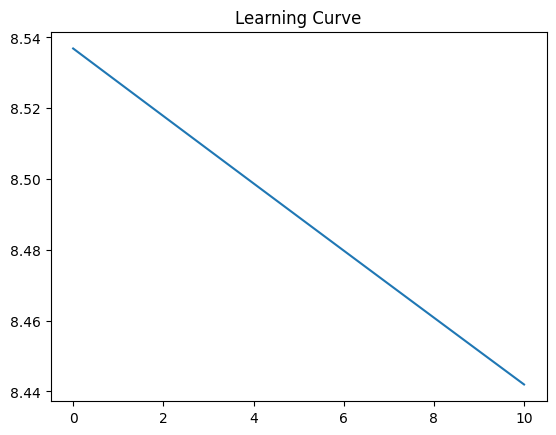

In [23]:
# test grad descent

test_losses, test_final_mlp = grad_descent(test_data, test_mlp, iterations=10, learning_rate=0.0001) # You may need to tune learning rate

plt.plot(np.arange(len(test_losses)), test_losses)
plt.title("Learning Curve")

4. Now we plot our model

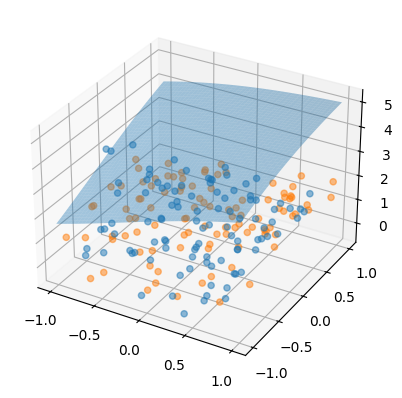

In [24]:
def plot_data_and_pred(my_mlp, train_points, test_points):
    '''
    This should plot the data as a 3d scatter and the prediction of the model (i.e. the forward)
    as a 3d surface (that is it should be across all possible values of x and y).
     
    Make sure that both the surface and the points are distinguishable
    '''
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.scatter(train_points[:,0], train_points[:,1], train_points[:,2], alpha=0.5)
    ax.scatter(test_points[:,0], test_points[:,1], test_points[:,2], alpha=0.5)

    xs, ys = np.meshgrid(np.linspace(-1,1,50), np.linspace(-1,1,50))
    grid = np.column_stack([xs.ravel(), ys.ravel()])
    a, zs = mlp_forward(my_mlp, grid)

    ax.plot_surface(xs, ys, zs.reshape(xs.shape), alpha=0.4)
    plt.show()
plot_data_and_pred(test_final_mlp, train_data, test_data)

# Section 6 (**) Hyperparameter Tuning (20 min)
Now we want to find a good MLP for a problem

Note on this section -- if any of the test data is used at any point to influence the choice of hyperparameters then your solution will be useless. 

1. First, let us observe the behavior of a one-layer vs two layer network on the above problem. Plot the learning curve (loss vs iteration) of a single-layer and two-layer network trained via your gradient descent. Then plot the surfaces of each compared to the training and testing data.

2. Now, train each, but reserve 20% of the *training data* and evaluate each model on that portion each iteration without training on it. Add these "validation" plots to the learning curve plot (each line of a given model should be the same color but the validation line should be dashed).

3. Design and code a procedure to choose the best hyperparameters (i.e. the arcitecture (e.g. layers/weight mat sizes, learning rate, loss func)) to fit to this data. You may only evaluate on the test data (or plot it) once you have chosen a final model. Your performance on this data is considered your final score here.